In [24]:
import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import datasets, transforms

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(torch.__version__)
print(device)

2.11.0+cu128
cuda


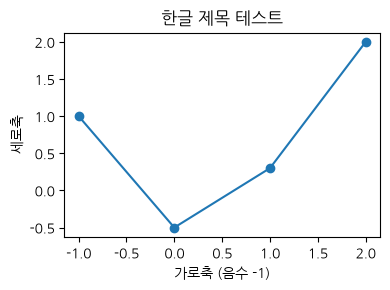

In [25]:
# 한글 폰트 설정 (나눔고딕)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

FONT_NAME = "NanumGothic"

# 설치된 폰트 목록에 나눔고딕이 있는지 확인
if FONT_NAME not in {f.name for f in fm.fontManager.ttflist}:
    # 혹시 폰트 캐시에 없으면 재스캔 시도
    fm._load_fontmanager(try_read_cache=False)

plt.rcParams["font.family"] = FONT_NAME
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

# 확인용 플롯
plt.figure(figsize=(4, 3))
plt.plot([-1, 0, 1, 2], [1, -0.5, 0.3, 2], marker="o")
plt.title("한글 제목 테스트")
plt.xlabel("가로축 (음수 -1)")
plt.ylabel("세로축")
plt.tight_layout()
plt.show()


In [26]:
base_dir = "./data"

if not os.path.isdir(base_dir):
    print("No Data!")

else:
    for split in ["train", "test"]:
        for cls in ["NORMAL", "PNEUMONIA"]:
            p = os.path.join(base_dir, split, cls)
            print(f"{split} / {cls:10s}: {len(os.listdir(p)):5d}장")

# 의료데이터라 Recall이 중요

train / NORMAL    :  1341장
train / PNEUMONIA :  3875장
test / NORMAL    :   242장
test / PNEUMONIA :   398장


In [27]:
# 상수 선언

batch_size = 32
image_size = 224
learning_rate = 5e-4
epochs = 2
class_labels = ["NORMAL", "PNEUMONIA"]

In [28]:
IMAGENET_MEAN = [0.485, 0.456, 0.206]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.RandomAffine(degrees = 0, translate = (0.1, 0.1), scale = (0.9, 1.1)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]
)

eval_tf = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]
)

In [29]:
train_full = datasets.ImageFolder(os.path.join(base_dir, "train"), transform = train_tf)
val_full = datasets.ImageFolder(os.path.join(base_dir, "train"), transform = eval_tf)
test_set = datasets.ImageFolder(os.path.join(base_dir, "test"), transform = eval_tf)

print(train_full.class_to_idx)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [30]:
n_total = len(train_full)
n_val = int(n_total * 0.2)
g = torch.Generator().manual_seed(42)
perm = torch.randperm(n_total, generator = g).tolist()
val_idx, train_idx = perm[:n_val], perm[n_val:]

train_set = Subset(train_full, train_idx)
val_set = Subset(val_full, val_idx)

train_loader = DataLoader(train_set, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val_set, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test_set, batch_size = batch_size, shuffle = False)

print(len(train_set), len(val_set), len(test_set))

4173 1043 640


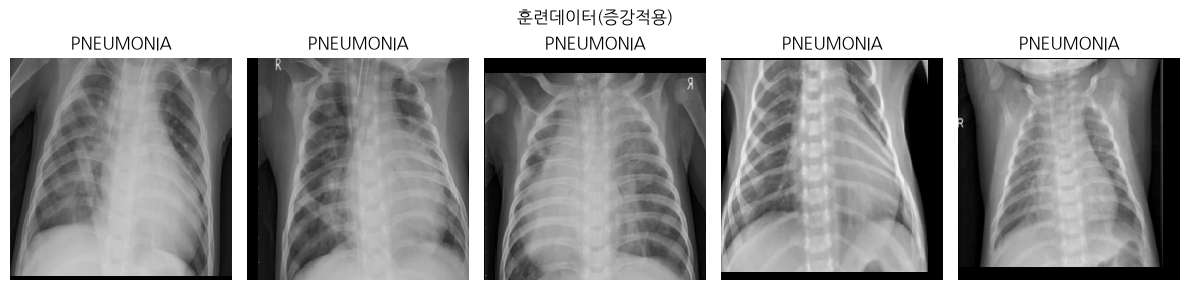

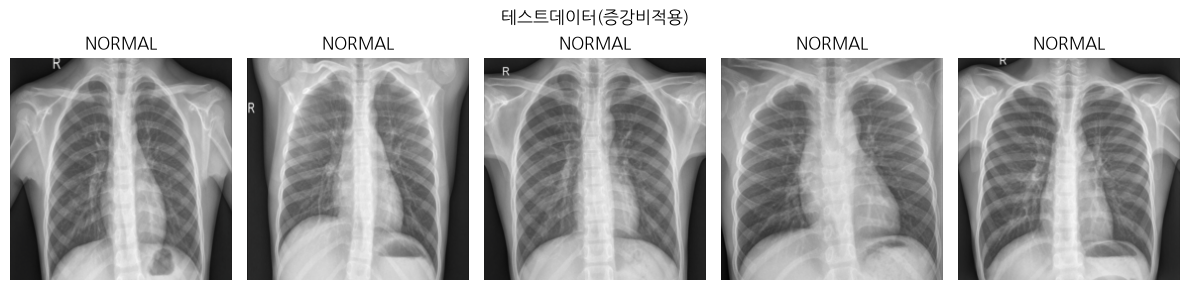

In [31]:
# 텐서로 변환하기 위한 Denormalize

def denormalize(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    return (t.cpu() * std + mean).clamp(0, 1)

def show_images(loader, num_images = 5, title = ""):
    images, labels = next(iter(loader))
    plt.figure(figsize = (12, 3))

    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(denormalize(images[i]).permute(1, 2, 0).numpy())
        plt.title(class_labels[int(labels[i])])
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_images(train_loader, title = "훈련데이터(증강적용)")
show_images(test_loader, title = "테스트데이터(증강비적용)")

In [32]:
# ResNet을 이용한 전이학습

import timm

class XrayNet(nn.Module):
    def __init__(self, pretrained = True):
        super().__init__()
        self.backbone = timm.create_model("resnetv2_50",
                                          pretrained = pretrained, num_classes = 0,
                                          global_pool = "avg")
        n_feat = self.backbone.num_features

        self.head = nn.Sequential(
            nn.Linear(n_feat, 128),
            nn.ReLU(inplace = True),
            nn.Dropout(0.1),
            nn.Linear(128 ,1)
        )

    def forward(self, x):
        return self.head(self.backbone(x))

model = XrayNet(pretrained = True)

with torch.no_grad():
    out = model(torch.zeros(2, 3, image_size, image_size))

print(f"출력 모양: {tuple(out.shape)}")
print(f"파라미터: {sum(p.numel() for p in model.parameters()):,}")

출력 모양: (2, 1)
파라미터: 23,762,753


In [33]:
from sklearn.metrics import (confusion_matrix, accuracy_score, recall_score, precision_score, roc_auc_score)

@torch.no_grad()
def evaluate(model, loader, criterion = None):
    model.eval()
    losses, probs, trues = [], [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.float().to(device)
        logits = model(xb).squeeze(1) # output

        if criterion is not None:
            losses.append(criterion(logits, yb).item() * len(yb))

        probs.append(torch.sigmoid(logits).cpu().numpy())
        trues.append(yb.cpu().numpy())

    probs = np.concatenate(probs)
    trues = np.concatenate(trues)

    preds = (probs > 0.5).astype(int)

    return {
        "loss": (sum(losses) / len(trues)) if criterion is not None else None,
        "accuracy": accuracy_score(trues, preds),
        "recall": recall_score(trues, preds, zero_division = 0),
        "precision": precision_score(trues, preds, zero_division = 0),
        "auc": roc_auc_score(trues, probs) if len(set(trues)) > 1 else float("nan"),
        "probs": probs,
        "trues": trues,
        "preds": preds
    }

def train_model(model, train_loader, val_loader, epochs = 20, lr = 5e-4, ckpt_path = "checkpoint.pt",
                label = "model"):
    model = model.to(device)
    # pw = (None if pos_weight is None else torch.tensor([pos_weight], dtype = torch.float32, device = device))
    criterion = nn.BCEWithLogitsLoss() # 두가지 분류할때 사용
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode = "min", factor = 0.1, patience = 2, min_lr = 1e-7
    )
    history = {k: [] for k in ["loss", "val_loss", "accuracy", "val_accuracy", "val_recall", "val_precision", "val_auc"]}
    best_val = float("inf")

    for epoch in range(1, epochs + 1):
        model.train()
        run_loss, run_correct, n = 0.0, 0, 0
        t0 = time.time()

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.float().to(device)
            optimizer.zero_grad()
            logits = model(xb).squeeze(1)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            run_loss += loss.item() * len(yb)
            run_correct += ((torch.sigmoid(logits) > 0.5).float() == yb).sum().item()
            n += len(yb)

        tr_loss, tr_acc = run_loss / n, run_correct / n

        m = evaluate(model, val_loader, criterion)
        scheduler.step(m["loss"])   # [수정] 추가: 스케줄러를 만들어놓고 호출 안 해서 LR이 안 줄었음

        history["loss"].append(tr_loss)
        history["accuracy"].append(tr_acc)
        history["val_loss"].append(m["loss"])
        history["val_accuracy"].append(m["accuracy"])
        history["val_recall"].append(m["recall"])
        history["val_precision"].append(m["precision"])
        history["val_auc"].append(m["auc"])

        star = ""
        # [수정] 원래 코드: if m["loss"] > best_val:
        #   best_val(=inf)보다 val_loss가 "커질 때" 저장 -> 절대 참이 안 됨 -> checkpoint.pt 저장 안 됨
        if m["loss"] < best_val:     # val_loss가 개선(감소)될 때만 저장
            best_val = m["loss"]
            torch.save(model.state_dict(), ckpt_path)
            star = "Saved!"

        print(f"[{label}] {epoch:02d} / {epochs}")
        print(f"Loss: {tr_loss:.4f} Val_Loss: {m['loss']:.4f}")
        print(f"Val_Acc: {m['accuracy']:.4f} Val_Auc: {m['auc']:.4f}")
        print(f"Learning_Rate: {optimizer.param_groups[0]['lr']:.1e}")
        print(f"{time.time() - t0: .0f} {star}")

    print(f"Best Loss = {best_val: .4f} {ckpt_path}")
    return history

In [34]:
model = XrayNet(pretrained = True)
history = train_model(model, train_loader, val_loader, epochs = epochs, lr = learning_rate)

[model] 01 / 2
Loss: 0.2758 Val_Loss: 0.1148
Val_Acc: 0.9626 Val_Auc: 0.9881
Learning_Rate: 5.0e-04
 73 Saved!
[model] 02 / 2
Loss: 0.1090 Val_Loss: 0.0716
Val_Acc: 0.9703 Val_Auc: 0.9961
Learning_Rate: 5.0e-04
 73 Saved!
Best Loss =  0.0716 checkpoint.pt


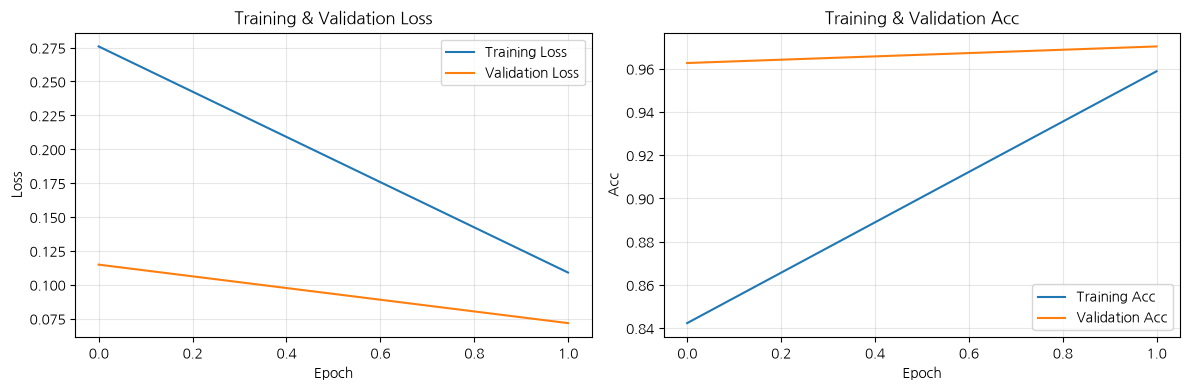

In [35]:
plt.figure(figsize = (12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label = "Training Loss")
plt.plot(history['val_loss'], label = "Validation Loss")
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha = 0.3)

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label = "Training Acc")
plt.plot(history['val_accuracy'], label = "Validation Acc")
plt.title("Training & Validation Acc")
plt.xlabel("Epoch")
plt.ylabel("Acc")
plt.legend()
plt.grid(alpha = 0.3)

plt.tight_layout()
plt.show()

In [36]:
best = XrayNet(pretrained = False).to(device)
best.load_state_dict(torch.load("checkpoint.pt", map_location = device))

m = evaluate(best, test_loader)
print(m['accuracy'], m['auc'])

0.8125 0.957462934507247


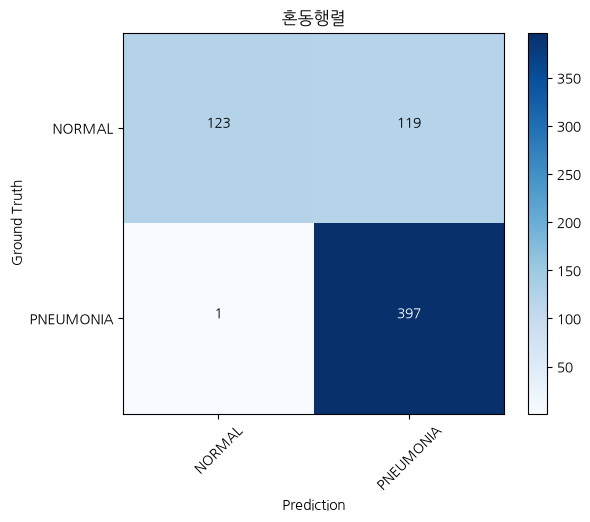

In [37]:
import itertools

def plot_confusion_matrix(cm, classes, normalize = False, title = "혼동 행렬", cmap = plt.cm.Blues):
    plt.imshow(cm, interpolation = "nearest", cmap = cmap)
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(classes))
    plt.xticks(ticks, classes, rotation = 45)
    plt.yticks(ticks, classes)

    if normalize:
        cm = cm.astype("float") / cm.sum(axis = 1)[:, np.newaxis]

    thresh = cm.max() / 2.

    # [수정] 원래 코드: for i, j in itertools.product(range(cm.shape[0])), range(cm.shape[1]):
    #   두 번째 range가 product() 밖에 있어서 i, j에 튜플이 들어가 좌표 에러 발생
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j ,i, cm[i, j], horizontalalignment = "center",
                 color = "white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel("Ground Truth")
    plt.xlabel("Prediction")

cm = confusion_matrix(m['trues'], m['preds'])
plt.figure(figsize = (6, 5))
plot_confusion_matrix(cm, classes = class_labels, title = "혼동행렬")